In [35]:
import numpy as np
import params
from basis import *
from matplotlib import pyplot as plt

import matplotlib.ticker as ticker


In [2]:
def create_cases(bog,allo_rate=10):
    init = np.array((0,  #A
                    0,  #B
                    0,  #P
                    bog*1.0 #S
                    ))
    
    allosteric_value = np.array((bog*1.0, #beta_s
                                1.,   #gamma_s
                                1,  #kAon
                                1,  #kAoff
                                10,  #kApon
                                1.,  #kApoff
                                1.,  #alpha
                                4.,  #alphap
                                10.,  #alpha_s
                                1.,  #alpha_sp
                                1.,  #nu
                                allo_rate*1.0, #nup
                                1., #kBon
                                1., #kBoff
                                1.  #gammaP
                                ))

    non_allost_value = np.array((bog*1.0, #beta_s
                                1.,   #gamma_s
                                11,  #kAon
                                2,  #kAoff
                                0,  #kApon
                                0,  #kApoff
                                0.,  #alpha
                                0,  #alphap
                                0.,  #alpha_s
                                0.,  #alpha_sp
                                (1.+allo_rate),  #nu
                                0., #nup
                                1., #kBon
                                1., #kBoff
                                1.  #gammaP
                                ))
    
    return params.case(init,allosteric_value),params.case(init,non_allost_value)



In [3]:
def find_steady(case):
    p=case.pinitial
    is_steady=False
    t=0
    while not(is_steady):
        p = case.solver(10,p)
        is_steady = case.found_steady_state(p)
        t+=10
    return p,t

In [4]:
def expected(prod,prob):
    return np.sum(prod*prob)

In [5]:
bog_list = [10.,20.,30.,40.,50.,60.,70.,80.]
bog_list = np.flip(bog_list)
log10_allo_rate_list = np.arange(-3,3.1,.5)
allo_rate_list = (10**log10_allo_rate_list)

In [6]:
S_steady_allo = []
S_steady_nonallo = []
MI_steady_allo = []
MI_steady_nonallo = []

for bog in bog_list:

    S_same_bog = []
    MI_same_bog =[]
    for allo_rate in allo_rate_list:
        allosteric,void = create_cases(bog,allo_rate)

        p_steady_allo,ta = find_steady(allosteric)
        print('solved allo (vals)',bog,allo_rate,ta)

        S_allo = expected(*marginalize(p_steady_allo, allosteric.states, 3) )
        MI_allo = mutual_info(*marginalize(p_steady_allo, allosteric.states, [0,1]))
        
        S_same_bog.append(S_allo)        
        MI_same_bog.append(MI_allo)

    S_steady_allo.append(S_same_bog) 
    MI_steady_allo.append(MI_same_bog) 

    allosteric,non_allosteric = create_cases(bog)
    p_steady_nonallo,tna = find_steady(non_allosteric)
    print('solved non-allo',bog,tna)

    S_nonallo = expected(*marginalize(p_steady_nonallo, non_allosteric.states, 3) )
    MI_nonallo = mutual_info(*marginalize(p_steady_nonallo, non_allosteric.states, [0,1]))

    S_steady_nonallo.append(S_nonallo)
    MI_steady_nonallo.append(MI_nonallo)





solved allo (vals) 80.0 0.001 60
solved allo (vals) 80.0 0.0031622776601683794 60
solved allo (vals) 80.0 0.01 50
solved allo (vals) 80.0 0.03162277660168379 50
solved allo (vals) 80.0 0.1 50
solved allo (vals) 80.0 0.31622776601683794 50
solved allo (vals) 80.0 1.0 40
solved allo (vals) 80.0 3.1622776601683795 30
solved allo (vals) 80.0 10.0 30
solved allo (vals) 80.0 31.622776601683793 30
solved allo (vals) 80.0 100.0 20
solved allo (vals) 80.0 316.22776601683796 20
solved allo (vals) 80.0 1000.0 20
solved non-allo 80.0 30
solved allo (vals) 70.0 0.001 60
solved allo (vals) 70.0 0.0031622776601683794 60
solved allo (vals) 70.0 0.01 60
solved allo (vals) 70.0 0.03162277660168379 50
solved allo (vals) 70.0 0.1 50
solved allo (vals) 70.0 0.31622776601683794 50
solved allo (vals) 70.0 1.0 40
solved allo (vals) 70.0 3.1622776601683795 30
solved allo (vals) 70.0 10.0 30
solved allo (vals) 70.0 31.622776601683793 30
solved allo (vals) 70.0 100.0 20
solved allo (vals) 70.0 316.22776601683796

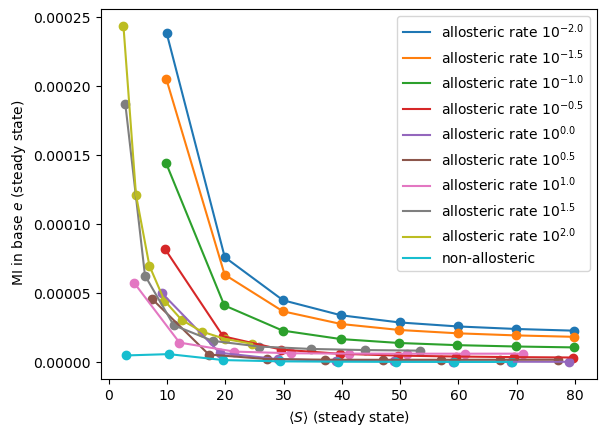

In [18]:
S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[plt.plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                          MI_steady_per_rate[2:-2],
                                                                                          allo_rate_list[2:-2])]
[plt.scatter(S,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]
plt.scatter(S_steady_nonallo,MI_steady_nonallo)
plt.plot(S_steady_nonallo,MI_steady_nonallo,label='non-allosteric')
plt.xlabel(r'$\langle S \rangle $ (steady state)')
plt.ylabel(' MI in base $e$ (steady state)')
plt.legend()

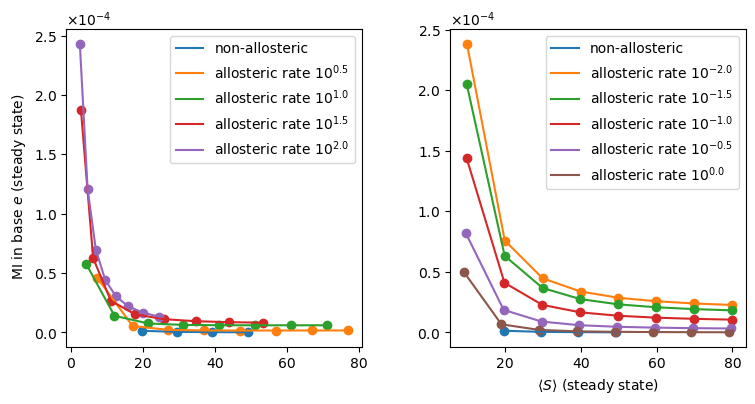

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[axi.scatter(S_steady_nonallo[2:-2],MI_steady_nonallo[2:-2]) for axi in ax]
[axi.plot(S_steady_nonallo[2:-2],MI_steady_nonallo[2:-2],label='non-allosteric') for axi in ax]

[ax[0].plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) if rate>1 else ax[1].plot(S,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                          MI_steady_per_rate[2:-2],
                                                                                          allo_rate_list[2:-2])]
[ax[0].scatter(S,MI)  if rate>1 else ax[1].scatter(S,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]

[axi.legend() for axi in ax]
plt.xlabel(r'$\langle S \rangle $ (steady state)')
ax[0].set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

for axi in ax:
    # Set the y-axis to scientific notation
    axi.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axi.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


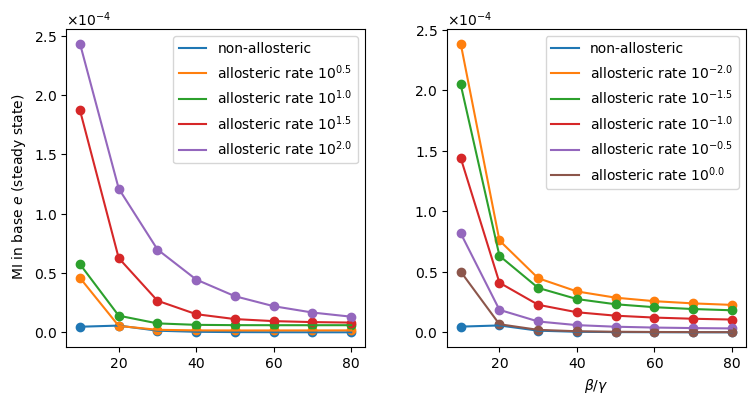

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

S_steady_per_rate = np.array(S_steady_allo).T
MI_steady_per_rate = np.array(MI_steady_allo).T

[axi.scatter(bog_list,MI_steady_nonallo) for axi in ax]
[axi.plot(bog_list,MI_steady_nonallo,label='non-allosteric') for axi in ax]

[ax[0].plot(bog_list,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) if rate>1 else ax[1].plot(bog_list,MI,label='allosteric rate $10^{{ {} }}$'.format(np.log10(rate))) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],
                                                                                                                                                                                                                  MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]
[ax[0].scatter(bog_list,MI)  if rate>1 else ax[1].scatter(bog_list,MI) for (S,MI, rate) in zip(S_steady_per_rate[2:-2],MI_steady_per_rate[2:-2],allo_rate_list[2:-2])]

[axi.legend() for axi in ax]
plt.xlabel(r'$\beta / \gamma$')
ax[0].set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

for axi in ax:
    # Set the y-axis to scientific notation
    axi.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    axi.ticklabel_format(style='sci', axis='y', scilimits=(0,0))


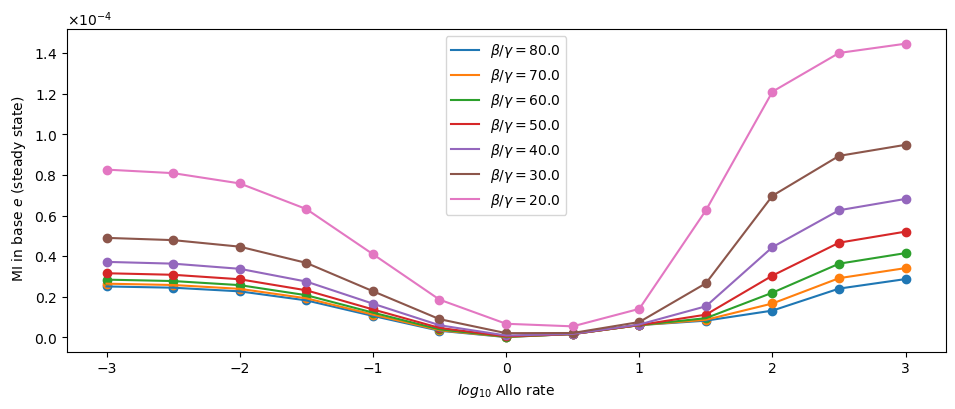

In [53]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

S_steady_per_bog = np.array(S_steady_allo)
MI_steady_per_bog = np.array(MI_steady_allo)

[ax.plot(np.log10(allo_rate_list),MI,label=r'$\beta / \gamma ={}$'.format(bog)) for MI,bog in zip(MI_steady_allo[:-1],bog_list[:-1]) ]
[ax.scatter(np.log10(allo_rate_list),MI) for MI,bog in zip(MI_steady_allo[:-1],bog_list[:-1]) ]


plt.xlabel(r'$log_{10}$ Allo rate')
ax.set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()